In [1]:
import os
import glob
import numpy as np
import pandas as pd
import pickle
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns

from scipy.ndimage import gaussian_filter1d

from scipy import stats
import statsmodels.formula.api as smf

# # For TF analysis
import scipy.fftpack
from scipy.fftpack import fft, ifft
from scipy import signal

sns.set_context('poster')
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

# import Python3_OpenOE_AC_map_functions_v1_08_30s as oem
import mz_LFP_functions as mz_LFP


%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
# for publication quality plots
def set_pub_plots(pal=sns.blend_palette(["gray","crimson", 'cyan', 'magenta', 'purple'  ],5)):
    sns.set_style("white")
    sns.set_palette(pal)
    sns.set_context("poster", font_scale=1.5, rc={"lines.linewidth": 2.5, "axes.linewidth":2.5, 'figure.facecolor': 'white'}) 
    sns.set_style("ticks", {"xtick.major.size": 8, "ytick.major.size": 8})
    # optional, makes markers bigger, too, axes.linewidth doesn't seem to work
    plt.rcParams['axes.linewidth'] = 2.5

rc_pub={'font.size': 25, 'axes.labelsize': 25, 'legend.fontsize': 25.0, 
    'axes.titlesize': 25, 'xtick.labelsize': 25, 'ytick.labelsize': 25, 
    #'axes.color_cycle':pal, # image.cmap - rewritesd the default colormap
    'axes.linewidth':2.5, 'lines.linewidth': 2.5,
    'xtick.color': 'black', 'ytick.color': 'black', 'axes.edgecolor': 'black','axes.labelcolor':'black','text.color':'black'}
# to restore the defaults, call plt.rcdefaults() 

#set_pub_bargraphs()
set_pub_plots()

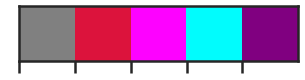

In [3]:
pal=sns.blend_palette(['gray','crimson','magenta','cyan','purple'],5)
sns.palplot(pal)
sns.set_palette(pal)

# Load some necessary variables

In [4]:
insert_depth = 3100  #change this as appropriate

sp_bw_ch = 20/2

surface_ch = np.round(insert_depth/sp_bw_ch)
V1_hip_ch = np.round((insert_depth-1000)/sp_bw_ch)
Hip_thal_ch = np.round((insert_depth-1000-1200)/sp_bw_ch)

CA1_DG_ch = np.round((insert_depth-1000-600)/sp_bw_ch)

print(surface_ch, V1_hip_ch, Hip_thal_ch, CA1_DG_ch)

310.0 210.0 90.0 150.0


In [5]:
samples_tr = 7350 #this is based on the shortest #samples in a trial
sr = 2500
n_chan = 384
rec_length = 3.0 #how long is the arduino triggered?

---

---

---

# First, load in the .npy array and CC_ls
These were creaded and saved using the "1_saving_LFP_arrays" jupyter notebook

In [6]:
allrecs_arr = np.load(r"D:\mz_Data\saved_dfs\Operant_reward\lfp_npy\novel_all_rew.npy")

pkl_file = r"D:\mz_Data\saved_dfs\Operant_reward\lfp_npy\novel_cc_ls"

open_file = open(pkl_file, "rb")
CC_ls = pickle.load(open_file)
open_file.close()

CC_ls

['CC067431',
 'CC067432',
 'CC067489',
 'CC067489',
 'CC082255',
 'CC082257',
 'CC082257',
 'CC082257',
 'CC082260',
 'CC082260',
 'CC082260',
 'CC082263',
 'CC082263',
 'CC082263',
 'CC084621',
 'CC084621']

# Time Frequency plots
### First, make some functions

In [7]:
def regroup(all_array, show=1):
    tf_groupA = []
    tf_groupB = []
    for i in range(all_array.shape[0]):
        if (CC_ls[i] == "CC082263") | (CC_ls[i] == "CC067489") | (CC_ls[i] == "CC082260") | (CC_ls[i] == "CC084621"):
            tf_groupA.append(all_array[i])
        elif (CC_ls[i] == "CC082257") | (CC_ls[i] == "CC067431") | (CC_ls[i] == "CC067432") | (CC_ls[i] == "CC082255"):
            tf_groupB.append(all_array[i])

    tf_groupA_arr = np.array(tf_groupA)
    tf_groupB_arr = np.array(tf_groupB)
    
    if show == 1:
        print(tf_groupA_arr.shape)
        print(tf_groupB_arr.shape)
    
    return tf_groupA_arr, tf_groupB_arr

In [8]:
def make_tf_data(group_arr):
    chs_ls = []
    for ii in range(group_arr.shape[0]):
        V1_region = group_arr[ii][200:300,:]
        min_ch = np.where(V1_region == np.amin(V1_region))
        min_ch2 = min_ch[0][0] + 199
        chs_ls.append(group_arr[ii][min_ch2,:])
        
    tf_plot = np.array(chs_ls)
    tf_plot_mean = np.mean(tf_plot, axis=0)
    tf_plot_mean = np.reshape(tf_plot_mean,(1,len(tf_plot_mean)))
    
    return tf_plot, tf_plot_mean

### Second, reestablish the A and B groups
These are 3d arrays with the following dimensions:
mice x ch x samples

In [9]:
A_novel, B_novel = regroup(allrecs_arr, show=0)


### Third, apply the functions to find the strongest ch averaged across all mice
It iterates through each mouse and find the strongest channel, which is appended to a list. The mean of this list is then used to plot the TF.

The important part is that the strongest channel from each mouse is used and not the overall strongest channel after averaging.
- Previous: average all recordings, then find strongest response
- Current: find strongest response for each mouse, then average

In [10]:
all_tf_A, mean_tf_A = make_tf_data(A_novel)
all_tf_B, mean_tf_B = make_tf_data(B_novel)

# this is just printing an example shape to make sure it worked correctly
print('Example dimension check! \nShould go from (n,7350) to (1,7350)\n')
print(all_tf_A.shape)
print(mean_tf_A.shape)

Example dimension check! 
Should go from (n,7350) to (1,7350)

(10, 7350)
(1, 7350)


### Fourth, plot the individual TF heatmaps for each group


In [11]:
groupA_plot = mean_tf_A
groupB_plot = mean_tf_B
plt_titleA = 'WT - Novel'
plt_titleB = 'FX - Novel'
fnA = "novel_A_heat.pdf"
fnB = "novel_B_heat.pdf"



C:\Users\AChub_Lab\Desktop\zimmer94\Data_Analysis\LFP\mz_LFP\Operant_reward\mz_LFP_functions.py:206: RuntimeWarning: invalid value encountered in true_divide
  tf[methodi,fi,:] = 10*np.log10( temppow / np.mean(temppow[base_idx[0]:base_idx[1]+1]) )


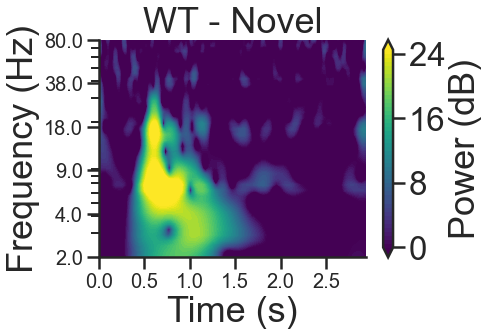

In [12]:
f,ax1=plt.subplots()
tf_A, time_A, frex_A, tf3d_A = mz_LFP.tf_cmw(ax=ax1, df_res=groupA_plot)

ax1.set_title(plt_titleA)
sns.despine()

# Change the end of this next line with a new file name!!
# plt.savefig(r"D:\mz_Data\DATA_Figs\Operant_Reward\novel_WT_TF.pdf", transparent=True)

plt.show()

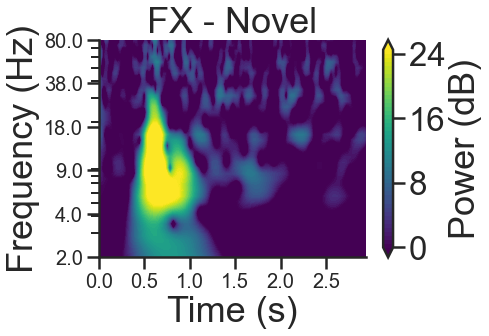

In [13]:
f,ax1=plt.subplots()
tf_B, time_B, frex_B, tf3d_B = mz_LFP.tf_cmw(ax=ax1, df_res=groupB_plot)

ax1.set_title(plt_titleB)
sns.despine()

# Change the end of this next line with a new file name!!
# plt.savefig(r"D:\mz_Data\DATA_Figs\Operant_Reward\novel_FX_TF.pdf", transparent=True)

plt.show()

### Fifth, rerun the TF code to extract the freq. band values
I have to rerun it on each mouse to get the confidence intervals

In [32]:
novelA_df = mz_LFP.TF_band_values(all_tf_A)
novelB_df = mz_LFP.TF_band_values(all_tf_B)

0


C:\Users\AChub_Lab\Desktop\zimmer94\Data_Analysis\LFP\mz_LFP\mz_LFP_functions.py:206: RuntimeWarning: invalid value encountered in true_divide
  tf[methodi,fi,:] = 10*np.log10( temppow / np.mean(temppow[base_idx[0]:base_idx[1]+1]) )


1


C:\Users\AChub_Lab\Desktop\zimmer94\Data_Analysis\LFP\mz_LFP\mz_LFP_functions.py:206: RuntimeWarning: invalid value encountered in true_divide
  tf[methodi,fi,:] = 10*np.log10( temppow / np.mean(temppow[base_idx[0]:base_idx[1]+1]) )


2


...

C:\Users\AChub_Lab\Desktop\zimmer94\Data_Analysis\LFP\mz_LFP\mz_LFP_functions.py:206: RuntimeWarning: invalid value encountered in true_divide
  tf[methodi,fi,:] = 10*np.log10( temppow / np.mean(temppow[base_idx[0]:base_idx[1]+1]) )


4


C:\Users\AChub_Lab\Desktop\zimmer94\Data_Analysis\LFP\mz_LFP\mz_LFP_functions.py:206: RuntimeWarning: invalid value encountered in true_divide
  tf[methodi,fi,:] = 10*np.log10( temppow / np.mean(temppow[base_idx[0]:base_idx[1]+1]) )


5


C:\Users\AChub_Lab\Desktop\zimmer94\Data_Analysis\LFP\mz_LFP\mz_LFP_functions.py:206: RuntimeWarning: invalid value encountered in true_divide
  tf[methodi,fi,:] = 10*np.log10( temppow / np.mean(temppow[base_idx[0]:base_idx[1]+1]) )


### Sixth, combine the two group dfs, maintaining an ID for each group

In [33]:
novelA_df['group'] = 'WT'
novelA_df['stim_id'] = 'novel'
novelB_df['group'] = 'FX'
novelB_df['stim_id'] = 'novel'


overall_tf = pd.concat([novelA_df, novelB_df])
overall_tf.head()

,id,variable,value,dB,group,stim_id
2,0,12-30Hz,1.093527,0.388294,WT,novel
4,0,30-40Hz,3.263352,5.136639,WT,novel
3,0,30-70Hz,0.487152,-3.123353,WT,novel
0,0,4-8Hz,6.687367,8.252552,WT,novel
5,0,50-70Hz,2.686809,4.292368,WT,novel


In [34]:
print(overall_tf.group.unique())
print(overall_tf.stim_id.unique())

['WT' 'FX']
['novel']


### Seventh, plot the frequency band values
separated out from each other by the different groups

In [38]:
TF_plot1 = overall_tf[overall_tf['stim_id'] == 'novel']
plt_title1 = 'Novel'

plt_yticks = [0,3,6,9,12]

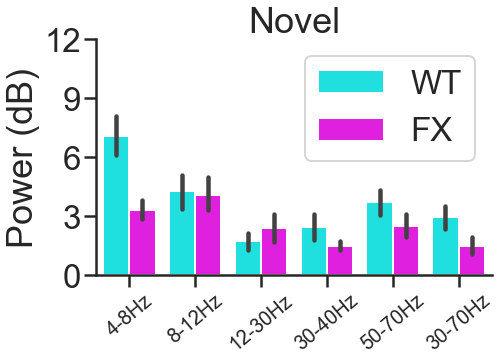

In [40]:
# Plotting the barplot of the T-F plot separated by group (time window = [0.7,2.2])

g = sns.catplot(x='variable', y='value', data=TF_plot1, kind = 'bar', 
                hue='group', hue_order=['WT','FX'], palette=sns.color_palette(['cyan', 'magenta']),
                legend=False,
                height = 5, aspect=1.5,
                order=['4-8Hz', '8-12Hz', '12-30Hz', '30-40Hz','50-70Hz','30-70Hz'], 
                ci=68)

g.set_xticklabels(['4-8Hz', '8-12Hz', '12-30Hz', '30-40Hz','50-70Hz','30-70Hz'],
                           rotation=40, fontsize=20)

plt.title(plt_title1)
plt.xlabel('')
plt.yticks(plt_yticks)
plt.ylabel('Power (dB)')
plt.legend(loc="upper right")
sns.despine()

# Change the end of this next line with a new file name!!
# plt.savefig(r"U:\Data\zimmer94\Operant_Reward\lfp\TF\1sec\novel_bar.pdf", transparent=True)


### Eighth, find the stats for the above plot

In [41]:
tf_groups = np.array(['4-8Hz','8-12Hz','12-30Hz','30-40Hz','50-70Hz','30-70Hz'])

stat_result = []
for ii in tf_groups:
    foo_A = TF_plot1[(TF_plot1['variable'] == ii) & (TF_plot1['group'] == 'WT')].value.values
    foo_B = TF_plot1[(TF_plot1['variable'] == ii) & (TF_plot1['group'] == 'FX')].value.values
    U, p = stats.mannwhitneyu(foo_A, foo_B)
    
    stat_result.append(ii)
    stat_result.append([U,p])

print(plt_title1)
stat_result

Novel


['4-8Hz',
 [8.0, 0.009760238561940096],
 '8-12Hz',
 [28.0, 0.4352837695647578],
 '12-30Hz',
 [25.0, 0.3124870814783532],
 '30-40Hz',
 [23.0, 0.240074454913567],
 '50-70Hz',
 [24.0, 0.2751074976735158],
 '30-70Hz',
 [16.0, 0.0712644040804669]]